SNIA:  0.04063645154149598
SIA:  0.017673941074541843


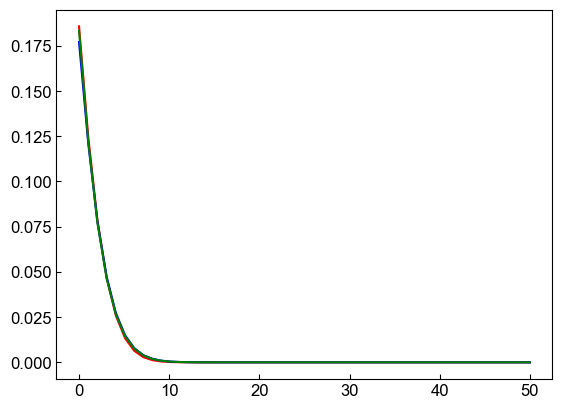

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# %matplotlib inline
# %config InlineBackend.figure_format = 'svg'
config = {'font.family': 'Arial',
          'font.size': 12,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
          'mathtext.fontset': 'stix',
          'savefig.dpi': 300
         }
plt.rcParams.update(config)

import flopy

model_ws = "./simulation/"
model_name = "model"

nlay, nrow, ncol = 57, 1, 135

# 读取离散化文件（DIS）
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, sim_name=model_name, verbosity_level=0)
gwf = sim.get_model("gwf_model")
bud = sim.get_model("gwf_model").output.budget()
# 读取所有SPDIS数据
# spdis_all = bud.get_data(text='DATA-SPDIS')
# spdis_all = bud.get_data(text='FLOW-JA-FACE')

Spe_data = sim.get_model("gwt_Spe_model").output.concentration().get_alldata().reshape(-1)

# Read mf6pqc results pH Cl Mg Ca Calcite Dolomite
results_benchmark = np.load("./output/results_base.npy")
results_snia_large = np.load("./output/results_snia.npy")
results_sia_large = Spe_data


x_values = np.linspace(0, 50, 50)

plt.plot(x_values, results_benchmark[-1, 0, :], color='r')
plt.plot(x_values, results_snia_large[-1, 0, :], color='b')
plt.plot(x_values, results_sia_large, color='g')


# plt.plot(x_values, results_snia_large[-1, 0, :], color='b')
# plt.plot(x_values, results_snia_large[-1, 0, :], color='orange')

print("SNIA: ", np.linalg.norm(results_snia_large[-1, 0, :] - results_benchmark[-1, 0, :]) / np.linalg.norm(results_benchmark[-1, 0, :]))
print("SIA: ", np.linalg.norm(Spe_data - results_benchmark[-1, 0, :]) / np.linalg.norm(results_benchmark[-1, 0, :]))

In [24]:
Spe_sia = Spe_data

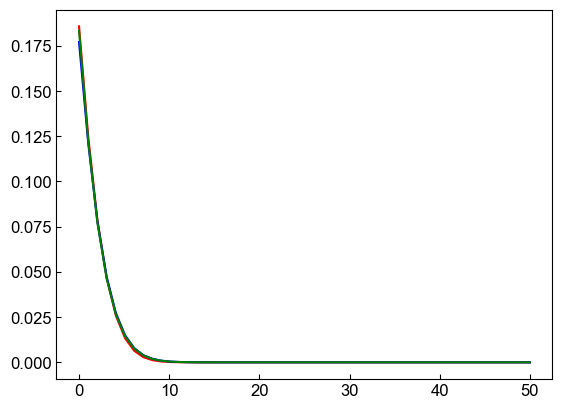

In [25]:
plt.plot(x_values, results_benchmark[-1, 0, :], color='r')
plt.plot(x_values, results_snia_large[-1, 0, :], color='b')
plt.plot(x_values, Spe_data, color='green')


In [26]:
np.linalg.norm(Spe_data - results_benchmark[-1, 0, :]) / np.linalg.norm(results_benchmark[-1, 0, :])

0.017673941074541843

In [27]:
np.linalg.norm(results_snia_large[-1, 0, :] - results_benchmark[-1, 0, :]) / np.linalg.norm(results_benchmark[-1, 0, :])

0.04063645154149598

In [28]:
# Spe_data1 = Spe_data

In [29]:
# plt.plot(x_values, results_benchmark[-1, 0, :], color='r')
# plt.plot(x_values, Spe_data2, color='b')
# plt.plot(x_values, Spe_data1, color='orange')

In [30]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

sim = flopy.mf6.MFSimulation.load(
    sim_ws="./simulation/",
    sim_name="model",
    verbosity_level=0
)

gwf = sim.get_model("gwf_model")
bud = sim.get_model("gwf_model").output.budget()
# 读取所有SPDIS数据
spdis_all = bud.get_data(text='DATA-SPDIS')

# spdis_all = bud.get_data(text='FLOW-JA-FACE')
# spdis0 = bud.get_data(text='DATA-SPDIS')[0]
# spdis30 = bud.get_data(text='DATA-SPDIS')[-1]

# 初始化空列表
qx_list, qy_list, qz_list, speed_list = [], [], [], []

# 循环计算每个时刻的比流量和流速
for spdis in spdis_all:
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
    speed = np.sqrt(qx**2 + qy**2 + qz**2)

    qx_list.append(qx)
    qy_list.append(qy)
    qz_list.append(qz)
    speed_list.append(speed)

# 堆叠为numpy数组，第0维是时间
qx_arr = np.stack(qx_list, axis=0)
qy_arr = np.stack(qy_list, axis=0)
qz_arr = np.stack(qz_list, axis=0)
speed_arr = np.stack(speed_list, axis=0)

print("qx_arr shape:", qx_arr.shape)   # (ntime, nlay, nrow, ncol)
print("speed_arr shape:", speed_arr.shape)
speed_arr / 0.20

qx_arr shape: (1, 1, 1, 50)
speed_arr shape: (1, 1, 1, 50)


array([[[[0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803,
          0.17006803, 0.17006803, 0.17006803, 0.17006803, 0.17006803]]]])